# Long Short-Term Memory (LSTM) Networks — Theory and Practice


# 1. Introduction to LSTMs

## What Is an LSTM?

LSTM stands for:

```text
Long Short-Term Memory
```

LSTMs are a special type of Recurrent Neural Network (RNN) designed to better handle:

* long-term dependencies
* sequence memory
* gradient stability

They were introduced to solve major limitations of vanilla RNNs.

---

## Why LSTMs Matter

Vanilla RNNs struggle when important information appears far earlier in the sequence.

Example:

```text
I grew up in France ... therefore I speak fluent French
```

The word:

```text
France
```

may appear dozens of tokens earlier.

Simple RNNs often forget such information.

LSTMs are designed to preserve important memory over long sequences.

---

## Common Applications

| Task                    | Example                     |
| ----------------------- | --------------------------- |
| Text generation         | Predict next character/word |
| Translation             | English → French            |
| Speech recognition      | Audio → Text                |
| Time-series forecasting | Stock prices                |
| Sentiment analysis      | Review classification       |
| Music generation        | Melody prediction           |

---

# 2. Why Vanilla RNNs Struggle

## Recap: Vanilla RNN

A standard RNN updates hidden state recursively:

$
h_t = \tanh(W_{xh}x_t + W_{hh}h_{t-1} + b_h)
$

---

## Problem: Vanishing Gradients

During Backpropagation Through Time (BPTT), gradients are repeatedly multiplied.

Example:

```text
0.9 × 0.9 × 0.9 × ...
```

Eventually gradients become extremely small.

Result:

* earlier information disappears
* long-term memory is lost
* training becomes difficult

---

## Exploding Gradients

Large repeated multiplications may also produce:

```text
1.5 × 1.5 × 1.5 × ...
```

Result:

* unstable updates
* NaN losses
* divergence

---

## RNN Memory Problem

Vanilla RNN hidden state acts like a compressed memory.

Over long sequences:

* useful information gets overwritten
* older context fades away

LSTMs introduce a more sophisticated memory mechanism.

---


# 3. LSTM Core Idea

## Main Innovation

LSTM introduces:

* explicit memory cell
* gating mechanisms
* controlled information flow

Instead of blindly overwriting hidden state.

---

## Key Components

| Component          | Purpose                       |
| ------------------ | ----------------------------- |
| Cell state $(C_t)$   | Long-term memory              |
| Hidden state $(h_t)$ | Current output                |
| Forget gate        | Remove irrelevant information |
| Input gate         | Add new information           |
| Output gate        | Control visible output        |

---

## Intuition

LSTM behaves like:

```text
Selective memory system
```

It learns:

* what to remember
* what to forget
* what to output

---

## Visual Intuition

```text
Previous Memory -----> Updated Memory
         ↑                  ↑
     Forget Gate       Input Gate
```

---


# 4. LSTM Architecture Overview

## Main Data Flow

At every time step:

Inputs:

* current input $x_t$
* previous hidden state $h_(t-1)$
* previous cell state $C_(t-1)$

Outputs:

* new hidden state $h_t$
* new cell state $C_t$

---

## Important Difference from RNN

Vanilla RNN:

```text
single hidden state
```

LSTM:

```text
hidden state + cell state
```

This extra cell state is the key improvement.

---

## Simplified Flow

```text
x_t + h_(t-1)
       ↓
  Forget Gate
       ↓
   Input Gate
       ↓
   Cell Update
       ↓
  Output Gate
       ↓
      h_t
```

---


# 5. Understanding LSTM Gates

## Forget Gate

**Purpose**

Decides:

```text
What information should be discarded?
```

Formula:

$
f_t = \sigma(W_f[h_{t-1}, x_t] + b_f)
$

Values close to:

* 0 → forget
* 1 → keep

---

## Input Gate

**Purpose**

Decides:

```text
What new information should be stored?
```

Formula:

$
i_t = \sigma(W_i[h_{t-1}, x_t] + b_i)
$

Candidate memory:

$
\tilde{C}*t = \tanh(W_c[h*{t-1}, x_t] + b_c)
$

---

## Cell State Update

### Memory Update

$
C_t = f_t * C_{t-1} + i_t * \tilde{C}_t
$

This is the core memory mechanism.

---

## Output Gate

**Purpose**

Controls what becomes visible as hidden state.

$
o_t = \sigma(W_o[h_{t-1}, x_t] + b_o)
$

Final hidden state:

$
h_t = o_t * \tanh(C_t)
$

---


# 6. LSTM Mathematics

## Full Equations

Forget gate:

$
f_t = \sigma(W_f[h_{t-1}, x_t] + b_f)
$

Input gate:

$
i_t = \sigma(W_i[h_{t-1}, x_t] + b_i)
$

Candidate memory:

$
\tilde{C}*t = \tanh(W_c[h*{t-1}, x_t] + b_c)
$

Cell state update:

$
C_t = f_t * C_{t-1} + i_t * \tilde{C}_t
$

Output gate:

$
o_t = \sigma(W_o[h_{t-1}, x_t] + b_o)
$

Hidden state:

$
h_t = o_t * \tanh(C_t)
$

---

## Important Observation

The cell state has an almost linear path through time.

This helps gradients flow much more effectively compared to vanilla RNNs.

---


# 7. Forward Pass Walkthrough

## Step-by-Step Intuition

Suppose:

```text
The weather today is very hot
```

LSTM can learn:

* "weather" matters
* "today" matters
* preserve useful context
* discard irrelevant details

---

## Conceptual Flow

**Step 1**

Forget irrelevant memory.

**Step 2**

Add useful new information.

**Step 3**

Update long-term memory.

**Step 4**

Generate visible hidden state.

---

# 8. Implementing LSTM From Scratch (NumPy)

In [3]:
# dataset
text = 'hello world. today is a beautiful day. dont worry, be happy'
chars = sorted(list(set(text)))

char_to_ix = {ch:i for i,ch in enumerate(chars)}
ix_to_char = {i:ch for ch,i in char_to_ix.items()}

In [4]:
# init params
import numpy as np

np.random.seed(1)

vocab_size = len(chars)
hidden_size = 16

# Input + hidden concatenated size
concat_size = vocab_size + hidden_size

In [5]:
# Weight Initialization
# Forget gate
Wf = np.random.randn(hidden_size, concat_size) * 0.01
bf = np.zeros((hidden_size, 1))

# Input gate
Wi = np.random.randn(hidden_size, concat_size) * 0.01
bi = np.zeros((hidden_size, 1))

# Candidate memory
Wc = np.random.randn(hidden_size, concat_size) * 0.01
bc = np.zeros((hidden_size, 1))

# Output gate
Wo = np.random.randn(hidden_size, concat_size) * 0.01
bo = np.zeros((hidden_size, 1))

# Hidden → output
Why = np.random.randn(vocab_size, hidden_size) * 0.01
by = np.zeros((vocab_size, 1))

In [6]:
# Helper Functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def softmax(x):
    x = x - np.max(x)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x)

In [7]:
# Initial States
h_prev = np.zeros((hidden_size, 1))
C_prev = np.zeros((hidden_size, 1))

In [8]:
# Single LSTM Forward Step
inputs = [char_to_ix[ch] for ch in 'hello']

for t in range(len(inputs)):

    # One-hot input vector
    x = np.zeros((vocab_size, 1))
    x[inputs[t]] = 1

    # Concatenate hidden state and input
    concat = np.vstack((h_prev, x))

    # Forget gate
    f_t = sigmoid(Wf @ concat + bf)

    # Input gate
    i_t = sigmoid(Wi @ concat + bi)

    # Candidate memory
    C_tilde = np.tanh(Wc @ concat + bc)

    # Cell state update
    C_prev = f_t * C_prev + i_t * C_tilde

    # Output gate
    o_t = sigmoid(Wo @ concat + bo)

    # Hidden state update
    h_prev = o_t * np.tanh(C_prev)

    # Output logits
    y = Why @ h_prev + by

    # Probabilities
    p = softmax(y)

    predicted_idx = np.argmax(p)

    print(ix_to_char[predicted_idx])

t
t
n
n
n


above simplified implementation shows:

* explicit memory cell
* gate operations
* controlled memory updates
* sequence processing

---



# 9. Character-Level Text Generation Example

Generate text one character at a time.


In [9]:
h_prev = np.zeros((hidden_size, 1))
C_prev = np.zeros((hidden_size, 1))

current_char = 'h'

generated = current_char

for _ in range(20):

    x = np.zeros((vocab_size, 1))
    x[char_to_ix[current_char]] = 1

    concat = np.vstack((h_prev, x))

    f_t = sigmoid(Wf @ concat + bf)
    i_t = sigmoid(Wi @ concat + bi)
    C_tilde = np.tanh(Wc @ concat + bc)

    C_prev = f_t * C_prev + i_t * C_tilde

    o_t = sigmoid(Wo @ concat + bo)

    h_prev = o_t * np.tanh(C_prev)

    y = Why @ h_prev + by

    p = softmax(y)

    idx = np.argmax(p)

    current_char = ix_to_char[idx]

    generated += current_char

print(generated)

htwsiiiiriiiriiiriiir


the model is untrained:

* output appear random
* but generation pipeline works correctly

---


# 10. Building LSTMs with PyTorch

Manual implementation is useful for learning.

PyTorch provides:

* automatic differentiation
* GPU acceleration
* optimized implementations
* batching support

In [29]:
import torch
import torch.nn as nn

class SimpleLSTM(nn.Module):

    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):

        output, (hidden, cell) = self.lstm(x)

        # Use final hidden state
        last_hidden = output[:, -1, :]

        return self.fc(last_hidden)

In [30]:
# dummy data

# Reproducibility
torch.manual_seed(1)

# Dataset parameters
batch_size = 64
seq_length = 10
input_size = 1

# Create random sequences
x = torch.randn(batch_size, seq_length, input_size)

# Create meaningful targets
#
# Rule:
# If sum of sequence values > 0 → class 1
# else → class 0
#
sequence_sums = x.sum(dim=1)

targets = (sequence_sums > 0).long().squeeze()

print("Input shape:", x.shape)
print("Targets shape:", targets.shape)

print(targets[:10])

Input shape: torch.Size([64, 10, 1])
Targets shape: torch.Size([64])
tensor([0, 1, 0, 1, 1, 1, 0, 0, 0, 1])


## Dataset Parameters Explained

1. `batch_size = 64`

How many sequences are processed in parallel.

```text
64 independent sequences per training step
```

Shape:

```python
x.shape = (batch_size, seq_length, input_size)
```

Meaning:

* 64 samples in one batch
* each sample is a full sequence

Example:

```text
Sequence 1: [...]
Sequence 2: [...]
...
Sequence 64: [...]
```

Why it matters:

* faster training (parallel computation)
* more stable gradients
* better GPU usage

---

2. `seq_length = 10`

Number of time steps in each sequence.

```text
Each sequence has 10 consecutive values
```

Example:

```text
x1 → x2 → x3 → ... → x10
```

Why it matters:

* defines how much history the model sees
* limits long-term dependency range
* affects training cost

Example sequence:

```text
[0.1, -0.2, 0.3, 0.8, -1.0, 0.5, 0.7, 0.2, -0.4, 0.9]
```

---

3. `input_size = 1`

Number of features per time step.

```text
Each time step contains a single value (scalar)
```

Example:

```text
[0.5], [-1.2], [0.8], ...
```

Common cases:

| input_size | Example                  |
| ---------- | ------------------------ |
| 1          | temperature, stock price |
| 10         | engineered features      |
| 300        | word embeddings          |
| 512+       | image embeddings         |

---

**Final Shape**

```python
x.shape = (64, 10, 1)
```

Meaning:

* 64 sequences
* each sequence has 10 steps
* each step has 1 value

---

**Visualization**

```text
Batch (64 sequences)
│
├── Sequence 1:  [x1, x2, x3, ..., x10]
├── Sequence 2:  [x1, x2, x3, ..., x10]
├── Sequence 3:  [x1, x2, x3, ..., x10]
...
└── Sequence 64: [x1, x2, x3, ..., x10]
```

Each x is a scalar because `input_size = 1`.

---


In [31]:
# Run Model
model = SimpleLSTM(
    input_size=1,
    hidden_size=32,
    output_size=2
)

out = model(x)

print(out.shape)

torch.Size([64, 2])


In [32]:
# Training Loop
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

for epoch in range(100):

    optimizer.zero_grad()

    outputs = model(x)

    loss = criterion(outputs, targets)

    loss.backward()

    optimizer.step()

    # Compute predictions
    predictions = torch.argmax(outputs, dim=1)

    accuracy = (predictions == targets).float().mean()

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:02d} | "
            f"Loss: {loss.item():.4f} | "
            f"Accuracy: {accuracy:.4f}"
        )

Epoch 00 | Loss: 0.6862 | Accuracy: 0.5312
Epoch 10 | Loss: 0.6700 | Accuracy: 0.7188
Epoch 20 | Loss: 0.6492 | Accuracy: 0.7812
Epoch 30 | Loss: 0.6130 | Accuracy: 0.8281
Epoch 40 | Loss: 0.5356 | Accuracy: 0.8906
Epoch 50 | Loss: 0.3890 | Accuracy: 0.9375
Epoch 60 | Loss: 0.3342 | Accuracy: 0.7969
Epoch 70 | Loss: 0.2761 | Accuracy: 0.9062
Epoch 80 | Loss: 0.2373 | Accuracy: 0.9688
Epoch 90 | Loss: 0.2007 | Accuracy: 0.9219


# 11. RNN vs LSTM Memory Evolution

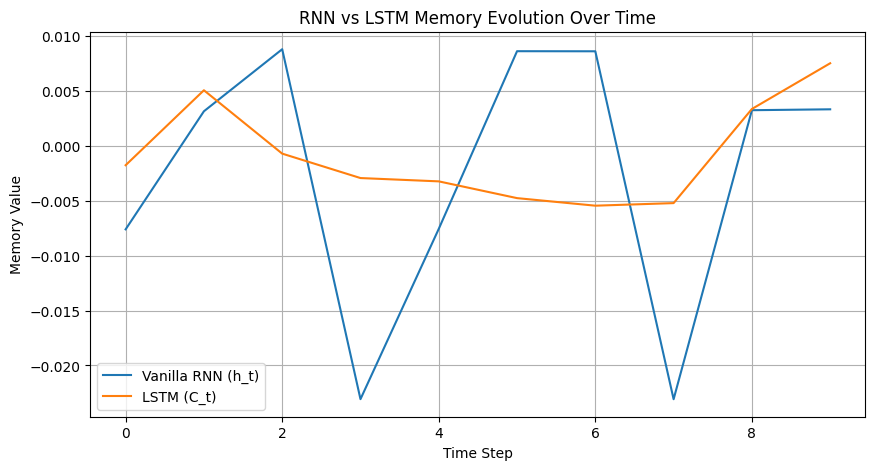

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Setup
# -------------------------
np.random.seed(1)

seq_length = 10
vocab_size = 5
hidden_size = 16

# random input sequence
inputs = np.random.randint(0, vocab_size, seq_length)

# -------------------------
# Activation functions
# -------------------------
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# -------------------------
# Shared LSTM dimensions
# -------------------------
concat_size = hidden_size + vocab_size

# -------------------------
# Vanilla RNN parameters
# -------------------------
Wxh = np.random.randn(hidden_size, vocab_size) * 0.01
Whh = np.random.randn(hidden_size, hidden_size) * 0.01
bh = np.zeros((hidden_size, 1))

# -------------------------
# LSTM parameters
# -------------------------
Wf = np.random.randn(hidden_size, concat_size) * 0.01
bf = np.zeros((hidden_size, 1))

Wi = np.random.randn(hidden_size, concat_size) * 0.01
bi = np.zeros((hidden_size, 1))

Wc = np.random.randn(hidden_size, concat_size) * 0.01
bc = np.zeros((hidden_size, 1))

Wo = np.random.randn(hidden_size, concat_size) * 0.01
bo = np.zeros((hidden_size, 1))

# =========================================================
# 1. VANILLA RNN MEMORY TRACKING
# =========================================================
h_prev = np.zeros((hidden_size, 1))
rnn_history = []

for t in range(seq_length):

    x = np.zeros((vocab_size, 1))
    x[inputs[t]] = 1

    # RNN update
    h_prev = np.tanh(Wxh @ x + Whh @ h_prev + bh)

    rnn_history.append(h_prev.copy())

rnn_history = np.array([h.flatten() for h in rnn_history])

# =========================================================
# 2. LSTM MEMORY TRACKING
# =========================================================
h_prev = np.zeros((hidden_size, 1))
C_prev = np.zeros((hidden_size, 1))
lstm_history = []

for t in range(seq_length):

    x = np.zeros((vocab_size, 1))
    x[inputs[t]] = 1

    concat = np.vstack((h_prev, x))

    # gates
    f_t = sigmoid(Wf @ concat + bf)
    i_t = sigmoid(Wi @ concat + bi)
    C_tilde = np.tanh(Wc @ concat + bc)

    # cell state (memory)
    C_prev = f_t * C_prev + i_t * C_tilde

    o_t = sigmoid(Wo @ concat + bo)

    h_prev = o_t * np.tanh(C_prev)

    lstm_history.append(C_prev.copy())

lstm_history = np.array([c.flatten() for c in lstm_history])

# =========================================================
# 3. VISUALIZATION
# =========================================================
plt.figure(figsize=(10, 5))

plt.plot(rnn_history[:, 0], label="Vanilla RNN (h_t)")
plt.plot(lstm_history[:, 0], label="LSTM (C_t)")

plt.title("RNN vs LSTM Memory Evolution Over Time")
plt.xlabel("Time Step")
plt.ylabel("Memory Value")
plt.legend()
plt.grid()
plt.show()

**Vanilla RNN**

* hidden state changes abruptly
* memory gets overwritten quickly
* unstable signal over time

**LSTM**

* smoother memory curve
* retains information longer
* controlled updates via gates


```text
RNN  → memory = h_t (fragile, overwritten)
LSTM → memory = C_t (controlled, persistent)
```

# 12. Time-Series Forecasting

In [89]:
# Generate Dataset
import numpy as np
import torch

np.random.seed(1)
torch.manual_seed(1)

# Create synthetic time series
t = np.linspace(0, 2000, 6000)
data = np.sin(t) + 0.5 * np.random.randn(len(t))

# sequence settings
seq_length = 20

def create_sequences(data, seq_length):
    X, y = [], []

    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])

    X = np.array(X)
    y = np.array(y)

    return X, y

X, y = create_sequences(data, seq_length)

# reshape for RNN/LSTM: (batch, seq, feature)
X = X[..., np.newaxis]
y = y[..., np.newaxis]

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

print(X.shape, y.shape)

torch.Size([5980, 20, 1]) torch.Size([5980, 1])


In [90]:
# Train/Test Split
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [91]:
# Vanilla RNN Model
import torch.nn as nn

class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32):
        super().__init__()

        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        last = out[:, -1, :]
        return self.fc(last)

In [92]:
# LSTM Model
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32):
        super().__init__()

        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, (h, c) = self.lstm(x)
        last = out[:, -1, :]
        return self.fc(last)

In [93]:
# Training Function
def train_model(model, X_train, y_train, epochs=30, lr=0.01):

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    losses = []

    for epoch in range(epochs):

        optimizer.zero_grad()

        pred = model(X_train)

        loss = criterion(pred, y_train)

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if epoch % 5 == 0:
            print(f"Epoch {epoch}: Loss = {loss.item():.4f}")

    return losses

In [94]:
# Train RNN
rnn_model = RNNModel()
rnn_losses = train_model(rnn_model, X_train, y_train)

Epoch 0: Loss = 0.7938
Epoch 5: Loss = 0.3580
Epoch 10: Loss = 0.3397
Epoch 15: Loss = 0.3254
Epoch 20: Loss = 0.3075
Epoch 25: Loss = 0.2803


In [95]:
# Train LSTM
lstm_model = LSTMModel()
lstm_losses = train_model(lstm_model, X_train, y_train)

Epoch 0: Loss = 0.7626
Epoch 5: Loss = 0.5728
Epoch 10: Loss = 0.3289
Epoch 15: Loss = 0.2891
Epoch 20: Loss = 0.2849
Epoch 25: Loss = 0.2785


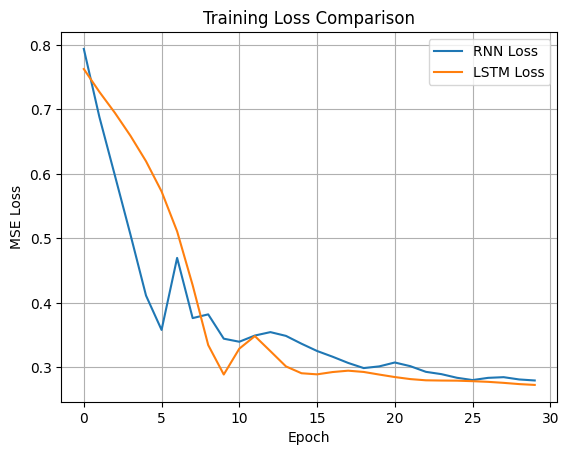

In [96]:
# Compare Loss Curves
import matplotlib.pyplot as plt

plt.plot(rnn_losses, label="RNN Loss")
plt.plot(lstm_losses, label="LSTM Loss")

plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid()
plt.show()

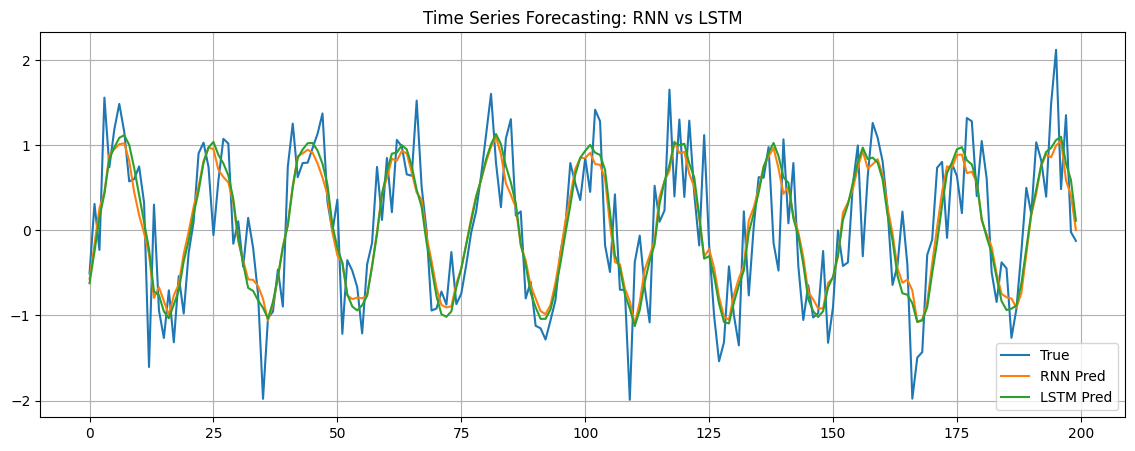

In [97]:
# Predictions Comparison
rnn_preds = rnn_model(X_test).detach().numpy()
lstm_preds = lstm_model(X_test).detach().numpy()

plt.figure(figsize=(14,5))

plt.plot(y_test[:200], label="True")
plt.plot(rnn_preds[:200], label="RNN Pred")
plt.plot(lstm_preds[:200], label="LSTM Pred")

plt.title("Time Series Forecasting: RNN vs LSTM")
plt.legend()
plt.grid()
plt.show()

## Conclusion: RNN vs LSTM (Sine Wave Time Series)

In this experiment, both RNN and LSTM were trained on a synthetic sine wave time series forecasting task.

**Key Result**

* Both models performed very similarly.
* LSTM achieved slightly lower loss, but the difference was small.

**Reason**

* The sine wave is a smooth, highly structured signal.
* Dependencies are short and predictable.
* Even a simple RNN is sufficient to learn the pattern.

**Takeaway**

* LSTM has a slight advantage in capturing smoother and longer dependencies.
* However, for simple periodic data, RNN is often already strong enough.
* Model complexity matters less when the underlying pattern is simple and stable.

---


# 13. Real Dataset: Stock Price Forecasting (AAPL)

In [ ]:
# !pip install yfinance -q

In [110]:
import yfinance as yf
import numpy as np
import torch
import matplotlib.pyplot as plt

# Download Apple stock data
df = yf.download("AAPL", start="2018-01-01", end="2026-01-01")

# We use only "Close" price
data = df["Close"].values

print(data.shape)

[*********************100%***********************]  1 of 1 completed

(2011, 1)


In [111]:
# Normalize Data
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data = scaler.fit_transform(data.reshape(-1, 1)).flatten()

In [112]:
# Create Sequences
# predict: past 30 days → next day price
seq_length = 30

def create_sequences(data, seq_length):
    X, y = [], []

    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])

    X = np.array(X)
    y = np.array(y)

    return X, y

X, y = create_sequences(data, seq_length)

X = X[..., np.newaxis]
y = y[..., np.newaxis]

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

print(X.shape, y.shape)

torch.Size([1981, 30, 1]) torch.Size([1981, 1])


In [113]:
# Train/Test Split
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [114]:
# Models (RNN vs LSTM)
import torch.nn as nn

class RNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(input_size=1, hidden_size=32, batch_first=True)
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])
    
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=32, batch_first=True)
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        out, (h, c) = self.lstm(x)
        return self.fc(out[:, -1, :])


In [115]:
# Training Loop
def train(model, X_train, y_train, epochs=50, lr=0.001):

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    losses = []

    for epoch in range(epochs):

        optimizer.zero_grad()

        pred = model(X_train)

        loss = criterion(pred, y_train)

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if epoch % 5 == 0:
            print(f"Epoch {epoch} | Loss: {loss.item():.6f}")

    return losses

In [116]:
# Train Models
rnn = RNNModel()
rnn_losses = train(rnn, X_train, y_train)

Epoch 0 | Loss: 0.051592
Epoch 5 | Loss: 0.032681
Epoch 10 | Loss: 0.031413
Epoch 15 | Loss: 0.025129
Epoch 20 | Loss: 0.021340
Epoch 25 | Loss: 0.015087
Epoch 30 | Loss: 0.009005
Epoch 35 | Loss: 0.002459
Epoch 40 | Loss: 0.001407
Epoch 45 | Loss: 0.001217


In [117]:
lstm = LSTMModel()
lstm_losses = train(lstm, X_train, y_train)

Epoch 0 | Loss: 0.188609
Epoch 5 | Loss: 0.152406
Epoch 10 | Loss: 0.118280
Epoch 15 | Loss: 0.085435
Epoch 20 | Loss: 0.053969
Epoch 25 | Loss: 0.028822
Epoch 30 | Loss: 0.026869
Epoch 35 | Loss: 0.027455
Epoch 40 | Loss: 0.021160
Epoch 45 | Loss: 0.020896


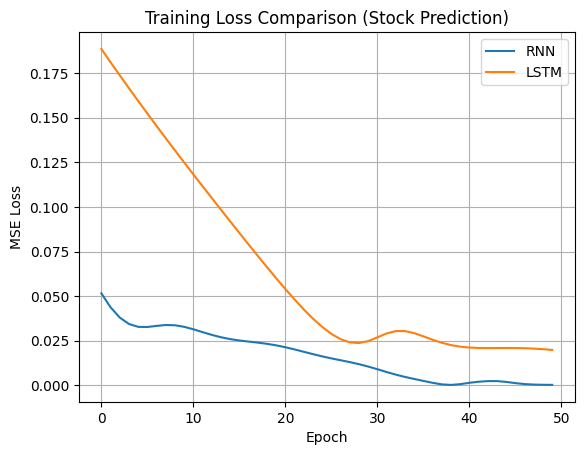

In [118]:
# Loss Comparison
plt.plot(rnn_losses, label="RNN")
plt.plot(lstm_losses, label="LSTM")

plt.title("Training Loss Comparison (Stock Prediction)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid()
plt.show()

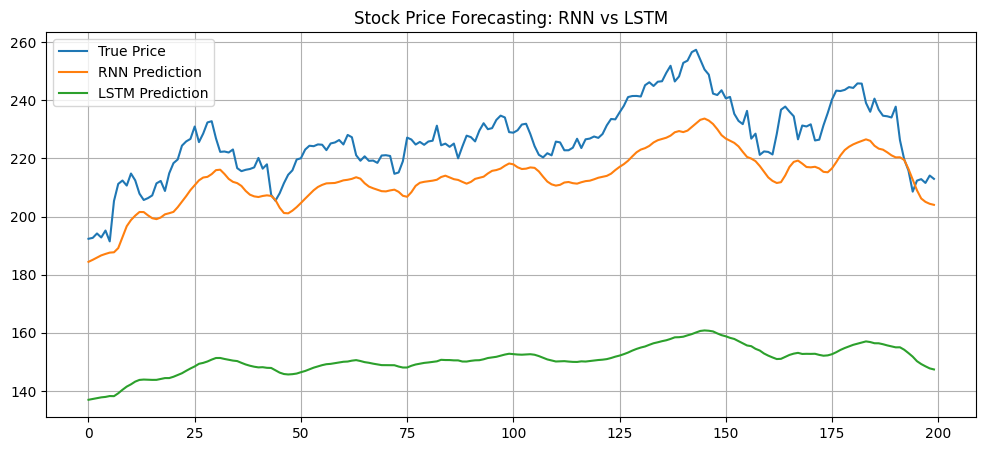

In [119]:
rnn_preds = rnn(X_test).detach().numpy()
lstm_preds = lstm(X_test).detach().numpy()

# invert scaling
y_test_real = scaler.inverse_transform(y_test)
rnn_real = scaler.inverse_transform(rnn_preds)
lstm_real = scaler.inverse_transform(lstm_preds)

plt.figure(figsize=(12,5))

plt.plot(y_test_real[:200], label="True Price")
plt.plot(rnn_real[:200], label="RNN Prediction")
plt.plot(lstm_real[:200], label="LSTM Prediction")

plt.title("Stock Price Forecasting: RNN vs LSTM")
plt.legend()
plt.grid()
plt.show()

## Conclusion: RNN vs LSTM (Stock Forecasting)

In this experiment, both RNN and LSTM were applied to stock price prediction.

**Key Result**

* RNN performed better than LSTM.

**Reason**

* Stock prices are highly noisy and weakly sequential in short windows.
* Long-term memory (LSTM advantage) was not strongly required.

**Takeaway**

* Simpler models like RNN can work well for short-horizon forecasting.
* LSTM is more useful when long-term dependencies are stronger and more structured patterns exist.

---


# 14. Long-Delay Memory Task

We create a synthetic sequence where:

The output depends ONLY on a value at the very beginning of the sequence.

| Model | Behavior                 |
| ----- | ------------------------ |
| RNN   | forgets first value      |
| LSTM  | retains long-term memory |


In [ ]:
# Dataset (Long Dependency Problem)
import numpy as np
import torch

np.random.seed(42)
torch.manual_seed(42)

seq_length = 50 # long sequence → key info is far away
num_samples = 2000

def generate_data(n, seq_length):
    X = []
    y = []

    for _ in range(n):
        first_value = np.random.randn()

        seq = np.random.randn(seq_length, 1)

        # inject signal ONLY at first position
        seq[0] = first_value

        label = 1 if first_value > 0 else 0

        X.append(seq)
        y.append(label)

    return np.array(X), np.array(y)

X, y = generate_data(num_samples, seq_length)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

print(X.shape, y.shape)

torch.Size([2000, 50, 1]) torch.Size([2000])


In [222]:
# Train/Test Split
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [223]:
import torch.nn as nn

class RNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(input_size=1, hidden_size=32, batch_first=True)
        self.fc = nn.Linear(32, 2)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])
    
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=32, batch_first=True)
        self.fc = nn.Linear(32, 2)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

In [224]:
# Training Loop
def train(model, X_train, y_train, epochs=60):

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    for epoch in range(epochs):

        optimizer.zero_grad()

        out = model(X_train)

        loss = criterion(out, y_train)

        loss.backward()
        optimizer.step()

        if epoch % 5 == 0:
            print(f"Epoch {epoch}: Loss {loss.item():.4f}")

In [225]:
rnn = RNNModel()
lstm = LSTMModel()

print("RNN Training")
train(rnn, X_train, y_train)

print("\nLSTM Training")
train(lstm, X_train, y_train)

RNN Training
Epoch 0: Loss 0.7051
Epoch 5: Loss 0.6930
Epoch 10: Loss 0.6910
Epoch 15: Loss 0.6904
Epoch 20: Loss 0.6901
Epoch 25: Loss 0.6899
Epoch 30: Loss 0.6895
Epoch 35: Loss 0.6893
Epoch 40: Loss 0.6886
Epoch 45: Loss 0.6535
Epoch 50: Loss 0.6676
Epoch 55: Loss 0.7340

LSTM Training
Epoch 0: Loss 0.6931
Epoch 5: Loss 0.6929
Epoch 10: Loss 0.6920
Epoch 15: Loss 0.6898
Epoch 20: Loss 0.6886
Epoch 25: Loss 0.6870
Epoch 30: Loss 0.6778
Epoch 35: Loss 0.6270
Epoch 40: Loss 0.6137
Epoch 45: Loss 0.5995
Epoch 50: Loss 0.6022
Epoch 55: Loss 0.5995


In [226]:
def accuracy(model, X, y):
    preds = model(X).argmax(dim=1)
    return (preds == y).float().mean().item()

print("RNN Accuracy:", accuracy(rnn, X_test, y_test))
print("LSTM Accuracy:", accuracy(lstm, X_test, y_test))

RNN Accuracy: 0.29499998688697815
LSTM Accuracy: 0.6600000262260437
